In [3]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score


In [4]:
#Load dataset
df = pd.read_csv(r"C:\Users\chris\Downloads\AirBnBDataset\AB_NYC_2019.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


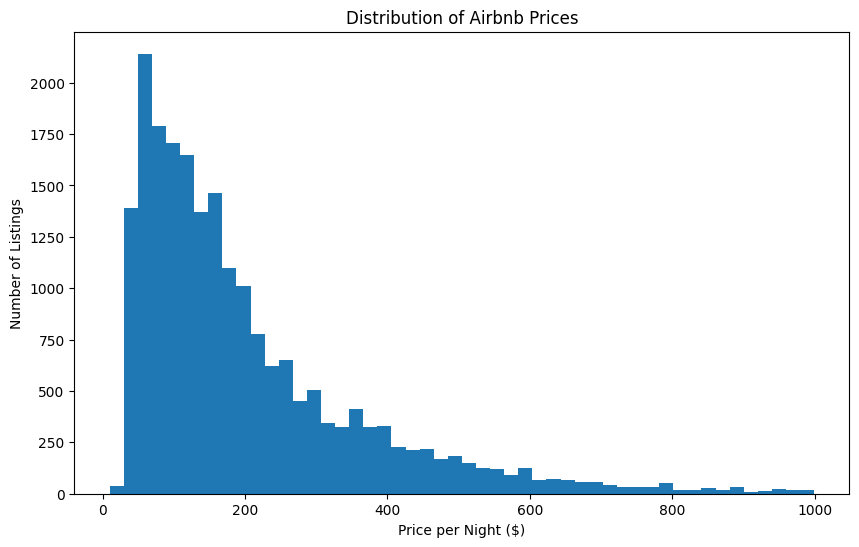

In [3]:
#Test data
raw_test_df = pd.read_csv(r"C:\Users\chris\Downloads\listings.csv.gz")

#We reserve all the prices to from our test set to compare with later
y_test_final = (
    raw_test_df["price"]
    .str.replace("$", "", regex=False)  # remove $ signs
    .str.replace(",", "", regex=False)  # remove commas
    .astype(float)                      # convert to float
    .copy()                              # make an independent copy
)

#Histogram plot of test data, cutting outliers
trial = y_test_final[y_test_final<1000]
plt.figure(figsize=(10,6))
plt.hist(trial, bins=50)  # bins control how many bars
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()



In [4]:
#Test data descriptive statistics
trial.describe()

count    20735.000000
mean       202.787413
std        164.245185
min         10.000000
25%         87.000000
50%        150.000000
75%        260.000000
max        999.000000
Name: price, dtype: float64

In [5]:
#Training data descriptive statistics
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [1]:
#Histogram plot
df = df[df['price']<600]
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50)  # bins control how many bars
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Prices")
plt.show()

NameError: name 'df' is not defined

In [7]:
#Identify columns with missing values
columns_with_missing_values_bool = df.isna().any()
print(columns_with_missing_values_bool)

#Feature engineering by combining the latitude and longitude columns into distance_manhattan, since we observed from previous tests that Manhattan neighborhood is very important.
df["distance_manhattan"] = np.sqrt((df["longitude"] - (-73.9855))**2 +
                                   (df["latitude"] - 40.7580)**2)

id                                False
name                               True
host_id                           False
host_name                          True
neighbourhood_group               False
neighbourhood                     False
latitude                          False
longitude                         False
room_type                         False
price                             False
minimum_nights                    False
number_of_reviews                 False
last_review                        True
reviews_per_month                  True
calculated_host_listings_count    False
availability_365                  False
dtype: bool


In [8]:
# Handle missing values
df = df.drop(columns=["name","host_id","host_name","id","last_review"]) #We are okay with dropping the identifiers and last_review cause the dates are annoying
df["reviews_per_month"] = df["reviews_per_month"].fillna(0) #If there are missing values for reviews_per_month, it could just be that it doesn't have reviews, so initialize to 0

# Categorical variable encoding
df = pd.get_dummies(df, columns=["neighbourhood_group", "neighbourhood", "room_type"]) #We just use one-hot encoding for everything here cause there is no ordinal data
print(df.columns)

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'distance_manhattan', 'neighbourhood_group_Bronx',
       ...
       'neighbourhood_Williamsbridge', 'neighbourhood_Williamsburg',
       'neighbourhood_Willowbrook', 'neighbourhood_Windsor Terrace',
       'neighbourhood_Woodhaven', 'neighbourhood_Woodlawn',
       'neighbourhood_Woodside', 'room_type_Entire home/apt',
       'room_type_Private room', 'room_type_Shared room'],
      dtype='object', length=236)


In [9]:
#Train test split
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [10]:
# Streamline test and training data

#This list represents all columns that our training data has, we could technically include distance_manhattan as well but I left that for next time
#This could probably have been much more efficient if I just used .columns on the original train set but oh well
cols_to_keep = [
    "neighbourhood_group", 
    "neighbourhood",
    "room_type",
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "price"
]

#Renaming the raw_test_df cause it would be weird to keep it all the time
X_test = raw_test_df.copy()

#The neighbourhood column is full of NaNs and there is another one called neighbourhood_cleansed which is better
X_test = X_test.drop("neighbourhood", axis = 1)

In [11]:
#Change the names so that they match the ones from our training set
X_test = X_test.rename(columns={
    "neighbourhood_group_cleansed": "neighbourhood_group",
    "neighbourhood_cleansed": "neighbourhood"
})

#Now we make sure that we only keep the columns we're interested in
X_test = X_test[cols_to_keep]

#Do the same review_per_month thing
X_test["reviews_per_month"] = X_test["reviews_per_month"].fillna(0)

#Do OH encoding on the X_test as well to match the train set
categorical_cols = ["neighbourhood_group", "neighbourhood", "room_type"]
X_test = pd.get_dummies(X_test, columns=categorical_cols)

#Make sure X_test only has columns that exist in X_train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [12]:
#Initialize model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,    
    reg_lambda=1.0
)

#This was used to get RMSE when doing train test split, not when using the separate dataset
scores = cross_val_score(
    model,          # your model
    X,              # your full feature matrix (no train-test split here)
    y,          # log-transformed price
    cv=5,           # 5-fold cross validation
    scoring="neg_mean_squared_error"
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
#Calculate the RMSE by comparing prediction and test set

#We identified earlier that the test set has insane outliers ($50000 price when the mean was like 200), so we have a cap to make sure our RMSE doesn't blow up
PRICE_CAP = 1000

#This mask will make sure that we only use the rows where there are no NaNs and if the price is less than the cap
mask = y_test_final.notna() & (y_test_final <= PRICE_CAP)

#Apply mask to both X_test and y_test with .loc to make sure the indexes are consistent
X_test_final = X_test.loc[mask]
y_test_filtered = y_test_final.loc[mask]

#Predict model as usual
y_pred = model.predict(X_test_final)

#The squared property in mean_squared_error() doesn't exist anymore, so instead we just need to get the MSE and square root it ourselves to get RMSE
mse = mean_squared_error(y_test_filtered, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")


RMSE: 147.48


In [14]:
#Looking at the results

#We make sure that the number of rows match and that there are no NaNs in the results
print(X_test_final.shape)
print(y_test_filtered.shape)
print(np.isnan(y_pred).sum(), "NaNs in predictions")


# Compare a few predictions vs actuals with their difference
comparison_df = pd.DataFrame({
    "Actual": y_test_filtered,
    "Predicted": y_pred,
    "Difference": abs(y_test_filtered - y_pred)
})

#Sort by the highest error generators
comparison_df = comparison_df.sort_values(by="Difference", ascending=False)

print(comparison_df.head(20))


(20755, 235)
(20755,)
0 NaNs in predictions
       Actual   Predicted  Difference
27470  1000.0  160.113297  839.886703
20362  1000.0  175.616150  824.383850
15106  1000.0  179.623718  820.376282
33179   930.0  118.514229  811.485771
26251   955.0  151.072296  803.927704
29642   967.0  165.725586  801.274414
13034   966.0  174.503571  791.496429
26344  1000.0  209.913071  790.086929
34238   958.0  169.841415  788.158585
25894  1000.0  212.077682  787.922318
12698   995.0  208.503677  786.496323
24612   999.0  213.054337  785.945663
13614   965.0  180.468475  784.531525
25567  1000.0  219.651794  780.348206
1632    950.0  171.372192  778.627808
20270   954.0  175.509232  778.490768
33121   990.0  212.958771  777.041229
30961  1000.0  223.586075  776.413925
20759   995.0  219.168350  775.831650
504    1000.0  226.448700  773.551300


In [15]:
#Feature importances to improve our model and construct special features
importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df.sort_values(by='importance', ascending=False, inplace=True)
print(importance_df.head(10))

                              feature  importance
232         room_type_Entire home/apt    0.181237
233            room_type_Private room    0.140919
10      neighbourhood_group_Manhattan    0.099116
234             room_type_Shared room    0.036884
7                  distance_manhattan    0.023475
139             neighbourhood_Midtown    0.023241
226        neighbourhood_Williamsburg    0.011249
9        neighbourhood_group_Brooklyn    0.009362
209             neighbourhood_Tribeca    0.009340
26   neighbourhood_Bedford-Stuyvesant    0.009108


In [16]:
#Calculate RMSE for train test split
rmse_scores = np.sqrt(-scores)
print("RMSE for each fold:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


RMSE for each fold: [66.5886319  62.21922087 59.24999176 61.51066584 74.42668569]
Average RMSE: 64.79903921104656
